# ___Phylogenetic traversal of independent ACEs of discrete and continuous traits___
---------------------------------------------------

In [1]:
print(R.version$version.string)

[1] "R version 4.5.2 (2025-10-31 ucrt)"


In [2]:
suppressPackageStartupMessages({
    library("ape")
    library("phytools")
    library("corHMM")
    library("diversitree")
    library("ggplot2")
})
# set.seed(2026-1-26)

In [3]:
STATES <- read.csv("../../data/chapter2/FREDv3subset/finalized_states_395_species.csv", stringsAsFactors = TRUE)[, c("binominal", "state")] # finalized mycorrhizal states
COLLAB_AXIS <- read.csv("../../data/chapter2/FREDv3subset/collab_ord1_species_avgs_SRL_RD.csv", stringsAsFactors = TRUE) # first order species averaged RD and SRL values
MERGED <- merge(x = STATES, y = COLLAB_AXIS, by = "binominal") # merge the two datasets into one, based on the binominal names
stopifnot(nrow(MERGED)==395)

PHYLOGENY <- ape::multi2di(ape::read.tree("../../data/chapter2/uphylomaker/FRED_subset_collab_395sp.tre")) # phylogenetic tree created for the 395 species using U.PhyloMaker
stopifnot(length(PHYLOGENY$tip.label)==395)

# MERGED contains spaces in the binominal names - replace that with underscores; and '/' in mycorrhizal states that need to be removed
data <- data.frame(binominal = gsub(MERGED$binominal, pattern = ' ', replacement = '_'), RD = MERGED$F00679, SRL = MERGED$F00727, myco = gsub(x = MERGED$state, pattern = '/', replacement = ''))
matched_row_indices <- match(PHYLOGENY$tip.label, data$binominal)
stopifnot(all(data$binominal[matched_row_indices] == PHYLOGENY$tip.label))
data <- data[matched_row_indices, ] # reorder the dataset to match the species order in the phylogeny
stopifnot(all(data$binominal == PHYLOGENY$tip.label))
stopifnot(length(unique(data$binominal)) == length(data$binominal))

load("../rdata/statesARD.RData") # load in the previously serialized ACEs of discrete character traits

Warning message in file(file, "rt"):
"cannot open file '../../data/chapter2/FREDv3subset/finalized_states_395_species.csv': No such file or directory"


ERROR: Error in file(file, "rt"): cannot open the connection


In [4]:
# FOR CONVENIRNCE
RD <- setNames(object = data$RD, nm = data$binominal)
SRL <- setNames(object = data$SRL, nm = data$binominal)
STATES <- setNames(object = data$myco, nm = data$binominal)

ERROR: Error in data$binominal: object of type 'closure' is not subsettable


In [16]:
table(STATES) # welp

STATES
   AM AMEcM  AMNM   EcM   ErM    NM 
  300    15     8    65     3     4 

## ___ACE of discrete categorical traits using `ape`, `corHMM`, `phytools` & `diversitree`___
------------------------------------------------------

In [5]:
ape::is.ultrametric(PHYLOGENY) # diversitree requires the phylogeny to be ultrametric

[1] TRUE

In [6]:
# diversitree::make.mkn requires the states to be encodes as numbers
STATES_TO_NUMERIC <- setNames(seq_along(unique(STATES)), unique(STATES)) # numeric encoding of the discrete character states
STATES_NUMERIC <- setNames(unname(STATES_TO_NUMERIC[unname(STATES)]), names(STATES)) # named vector for states with numeric encodings

In [7]:
# diversitree::make.mk2() can only be used with binary state discrete characters
fnlikelihood <- diversitree::make.mkn(tree = PHYLOGENY, states = STATES_NUMERIC, k = length(unique(STATES)))

In [8]:
fnlikelihood

Mk(n) likelihood function:
  * Parameter vector takes 30 elements:
     - q12, q13, q14, q15, q16, q21, q23, q24, q25, q26, q31, q32, q34,
       q35, q36, q41, q42, q43, q45, q46, q51, q52, q53, q54, q56, q61,
       q62, q63, q64, q65
  * Function takes arguments (with defaults)
     - pars: Parameter vector
     - root [ROOT.OBS]: Type of root treatment
     - root.p [NULL]: Vector of root state probabilities
     - intermediates [FALSE]: Also return intermediate values?
  * Phylogeny with 395 tips and 394 nodes
     - Taxa: Anaphalis_aureopunctata, Anaphalis_hancockii, ...
  * References:
     - Pagel (1994)
     - Lewis (2001)
R definition:
function (pars, root = ROOT.OBS, root.p = NULL, intermediates = FALSE)

In [40]:
# pars argument of the likelihood function
# for make.mkn, a vector of k(k-1) parameters, in the order q12,q13,...q1k, q21,q23,...,q2k,...qk(k-1),
# corresponding to the off-diagonal elements of the Q matrix in row order. The order of parameters can be seen by running argnames(f)

# in our case k is 6, so we need (6x(6-1)) 30 values???

In [10]:
tm <- Sys.time()
# this is an ARD model
dtmod <- diversitree::find.mle(func = fnlikelihood, x.init = rep(x = 1, times = 30), # x.init and any extra args will get passed to the likelihood function
                      root = diversitree::ROOT.FLAT)
# needs a bit more work to run properly :(
tm <- Sys.time() - tm

Warning message in mle.search(func2, x.init, control, lower, upper):
"Convergence problems in find.mle (subplex): number of function evaluations exceeds 'maxit'"


In [7]:
tm

Time difference of 12.70665 mins

In [6]:
head(ace_mystates_ape$lik.anc) # ACEs from ape::ace

,AM,AMEcM,AMNM,EcM,ErM,NM
,0.1780128,0.1676519782,0.1678403036,1.578790e-01,0.1634351304,0.1651807701
Spermatophyta,0.6310866,0.0084835214,0.0046855818,3.366856e-01,0.0104656214,0.0085930809
Mesangiospermae,0.9977981,0.0008962305,0.0007030107,4.117119e-05,0.0001865737,0.0003748925
mrcaott2ott121,0.9976927,0.0009171114,0.0008248579,5.346829e-06,0.0001821443,0.0003778518
eudicotyledons,0.9955822,0.0018531260,0.0015132375,1.289059e-04,0.0003336385,0.0005888917
mrcaott2ott969,0.9940667,0.0023077572,0.0023268170,7.445513e-05,0.0004406938,0.0007835858


In [7]:
head(ace_mystates_ancr$ace) # ACEs from phytools::ancr

,AM,AMEcM,AMNM,EcM,ErM,NM
396,0.0922244,5.397558e-05,4.223003e-01,6.549021e-04,0,4.847664e-01
397,0.5235107,7.513800e-05,2.002798e-01,6.545492e-04,0,2.754798e-01
398,0.9998722,3.853322e-14,7.447998e-05,1.675982e-08,0,5.331681e-05
399,0.9998850,1.748693e-12,6.994310e-05,6.788944e-09,0,4.503764e-05
400,0.9997399,1.083204e-11,2.386851e-04,2.615169e-08,0,2.134789e-05
401,0.9998144,1.764122e-10,1.683307e-04,6.426645e-08,0,1.716133e-05


In [8]:
head(ace_mystates_hmm$states) # ACEs from corHMM

"(1,R1)","(2,R1)","(3,R1)","(4,R1)","(5,R1)","(6,R1)"
0.7384633,1.040288e-04,0.0994976039,6.260653e-03,6.030534e-04,1.550713e-01
0.8501157,7.903288e-04,0.0747048386,5.612279e-03,2.847190e-05,6.874840e-02
0.9991916,9.818027e-13,0.0008082208,7.337873e-08,1.788241e-15,1.214591e-07
0.9992163,2.685532e-11,0.0007836026,3.027913e-08,2.436969e-14,8.614221e-08
0.9989217,2.534694e-10,0.0010780045,5.338445e-08,3.126602e-12,2.003021e-07
0.9990869,3.113141e-09,0.0009128237,1.242300e-07,2.405557e-12,1.708078e-07


In [12]:
# the output of corHMM lacks explicit column names (mycorrhizal states)
# outputs of ape and corHMM lack explicit row names (node numbers)

## ___Manual phylogeny traversal using presaved ACEs of discrete trait___
---------------------------

In [203]:
ace_mystates_hmm


Fit
      -lnL      AIC     AICc Rate.cat ntax
 -127.3412 314.6825 319.7924        1  395

Legend
      1       2       3       4       5       6 
   "AM" "AMEcM"  "AMNM"   "EcM"   "ErM"    "NM" 

Rates
            (1,R1)       (2,R1)       (3,R1)      (4,R1)       (5,R1)
(1,R1)          NA 0.0003220296 0.0009737899 0.000201527 6.729156e-05
(2,R1) 0.000000001           NA 0.0000000010 0.017445718 1.000000e-09
(3,R1) 0.016863141 0.0000000010           NA 0.000000001 1.000000e-09
(4,R1) 0.001299564 0.0000000010 0.0000000010          NA 1.000000e-09
(5,R1) 0.000000001 0.0000000010 0.0000000010 0.000000001           NA
(6,R1) 0.000000001 0.0000000010 0.0071694536 0.000000001 1.000000e-09
             (6,R1)
(1,R1) 1.000000e-09
(2,R1) 1.000000e-09
(3,R1) 1.027515e-02
(4,R1) 1.000039e-09
(5,R1) 9.735390e-04
(6,R1)           NA

Arrived at a reliable solution 

In [17]:
# based on the legend of the corHMM model output
STATES_LEGEND_CORHMM <- c("AM", "AMEcM", "AMNM", "EcM", "ErM", "NM")
STATES_LEGEND_CORHMM

[1] "AM"    "AMEcM" "AMNM"  "EcM"   "ErM"   "NM"

In [18]:
state_preds_hmm <- STATES_LEGEND_CORHMM[apply(ace_mystates_hmm$states, MARGIN = 1, FUN = which.max)] # MARGIN = 1 is used for row wise apply

# colnames(ace_mystates_ancr$ace)
state_preds_phy <- colnames(ace_mystates_ancr$ace)[apply(ace_mystates_ancr$ace, MARGIN = 1, FUN = which.max)] # only the output of phytools::ancr has explicit node numbers as row names!!

# colnames(ace_mystates_ape$lik.anc)
state_preds_ape <- colnames(ace_mystates_ape$lik.anc)[apply(ace_mystates_ape$lik.anc, MARGIN = 1, FUN = which.max)]

In [19]:
mean(state_preds_ape == state_preds_hmm)

[1] 0.9720812

In [20]:
mean(state_preds_ape == state_preds_phy) # the lowest

[1] 0.9492386

In [21]:
mean(state_preds_phy == state_preds_hmm) # the highest

[1] 0.9771574

In [22]:
all(rownames(ace_mystates_ancr$ace) == 396:789) # internal node names

[1] TRUE

In [23]:
# let's stick to the reconstructions of corHMM for the discrete character
internode_states <- setNames(state_preds_hmm, nm = rownames(ace_mystates_ancr$ace))

stopifnot(all(PHYLOGENY$tip.label == names(STATES)))
all_states <- c(setNames(unname(STATES), nm = as.character(1:395)), # tips (available data)
                                    internode_states) # internodes (reconstructed data)
stopifnot(length(all_states) == PHYLOGENY$Nnode + length(PHYLOGENY$tip.label))

In [174]:
# ace_mystates_dvt <- diversitree::

In [29]:
#--------------------------------
# ACE OF CONTINUOUS TRAITS
#--------------------------------

ace_srl_fastanc <- phytools::fastAnc(tree = PHYLOGENY, x = SRL, vars = TRUE, CI = TRUE) # this is a Maximim Likelihood (ML) based method - Brownian motion models which essentially is a Markov process on a continuous scale
# https://eeob-macroevolution.github.io/Practicals/Ancestral_State_Estimation/AncStateEstimation_Tutorial.html
# the link above provides detailed info on ACE, and also recommends incorporating fossil data when available to make the ACE more rigorous
# do we have fossil root trait data???????

# Liam J. Revell's website says that phytools::fastAnc also uses Felsenstein's re-rooting algorithm for ACE of continuous characters - http://www.phytools.org/Cordoba2017/ex/7/Anc-states-continuous.html
# PCMIR (page 224) recommends fitting phytools::fastAnc with vars=TRUE, CI=TRUE as ACE happens with lots of uncertainty, so it's important to know the CIs of each reconstruction
ace_rd_fastanc <- phytools::fastAnc(tree = PHYLOGENY, x = RD, vars = TRUE, CI = TRUE) # repeat the above for RD

In [28]:
# examine the variances and confidence intervals of the ACE of the continuous trait
head(ace_srl_fastanc$CI95)

396,-521.88296,696.2604
397,-469.20576,617.9810
398,-95.15662,268.0453
399,-94.00978,267.6452
400,-81.94660,263.1486
401,-79.43571,260.9921


In [30]:
# see if the ACEs fall within the respective 95% CIs (BUT THESE 95% CIs ARE REALLY BROAD?????)
mean(ace_srl_fastanc$CI95[, 2] >= ace_srl_fastanc$ace) # estimates lesses than or equal to the upper bound
mean(ace_srl_fastanc$CI95[, 1] <= ace_srl_fastanc$ace) # estimates greater than or equal to the lower bound

[1] 1

[1] 1

In [31]:
# check the 95% CIs for RD
mean(ace_rd_fastanc$CI95[, 1] <= ace_rd_fastanc$ace) # lower bound <= ACE
mean(ace_rd_fastanc$CI95[, 2] >= ace_rd_fastanc$ace) # upper bound >= ACE

[1] 1

[1] 1

In [32]:
all_srl <- c(setNames(SRL, nm = as.character(1:395)), # tip SRL values
                      ace_srl_fastanc$ace) # reconstructed SRL values
all_rd <- c(setNames(RD, nm = as.character(1:395)), ace_rd_fastanc$ace) # do the same for SRL

stopifnot(length(all_srl) == PHYLOGENY$Nnode + length(PHYLOGENY$tip.label))
stopifnot(length(all_rd) == PHYLOGENY$Nnode + length(PHYLOGENY$tip.label))

In [33]:
nodedata <- data.frame(SRL = all_srl, RD = all_rd, STATE = all_states) # includes the extant and reconstructed clade trait data
head(nodedata)

,SRL,RD,STATE
,<dbl>,<dbl>,<chr>
1,479.1550,0.136950,AMNM
2,319.8579,0.178700,AM
3,202.8837,0.248225,AM
4,219.2008,0.211300,AM
5,297.1100,0.197000,AM
6,204.1529,0.167200,AM


In [34]:
# the plan here is to find out the (2) nodes at each branch of the phylogeny and capture and store the changes in SRL and mycorrhizal states corresponding to the branches
# we can start this with the internodes as the tips can only be at the descendent end of a branch, never at an ancestor end

In [35]:
head(PHYLOGENY$edge) # the edge attribute of the phylo object contains all the edge details, where each row corresponds to a branch in the phylogeny

396,397
397,398
398,399
399,400
400,401
401,402


In [36]:
transitions <- list() # figure out all the discrete state transitions included in our reconstruction - this will be common for RD & SRL
changes_srl <- vector(length = nrow(PHYLOGENY$edge), mode = "double")
changes_rd <- vector(length = nrow(PHYLOGENY$edge), mode = "double")

for (i in 1:nrow(PHYLOGENY$edge)) {
    # PHYLOGENY$edge[i, ] returns a tuple of node numbers defining a branch (from, to)
    from <- PHYLOGENY$edge[i, ][1] # ancestor
    to <- PHYLOGENY$edge[i, ][2] # descendent

    # corresponding state transition
    transitions[[i]] <- c(nodedata[from, "STATE"], nodedata[to, "STATE"])

    # corresponding continuous trait change
    changes_srl[i] <- (nodedata[from, "SRL"] - nodedata[to, "SRL"]) # SRL of ancestor - SRL of the descendent
    changes_rd[i] <- (nodedata[from, "RD"] - nodedata[to, "RD"]) # RD of ancestor - RD of the descendent
    # print(paste0(nodedata[from, "SRL"], ' ', nodedata[to, "SRL"]))
}

In [ ]:
paired_changes <- function(phylogeny, rdextant, srlextant, discextant, rdinternodes, srlinternodes, discinternodes) {
    # the phylogeny object that the continuous and discrete trait models were fitted with
    # rdextant - a named vector of RD values for the extant taxa in the phylogeny
    # srlextant - a named vector of SRL values for the extant taxa in the phylogeny
    # discextant - a named vector of discrete trait values for the extant taxa in the phylogeny

    # rdinternodes - ACE of RD of the internal nodes in the phylogeny (numeric vector)
    # srlinternodes - ACE of SRL of the internal nodes in the phylogeny (numeric vector)
    # discinternodes - ACE probabilities of the states for the internal nodes in the phylogeny (data.frame)
    
    # the tip labels of the phylogeny are expected to match with the names of the named trait vectors
    stopifnot(all(phylogeny$tip.label==names(rdextant)))
    stopifnot(all(phylogeny$tip.label==names(srlextant)))
    stopifnot(all(phylogeny$tip.label==names(discextant)))

    stopifnot(length(rdinternodes)==length(srlinternodes))
    stopifnot()
    
}

In [215]:
changes_srl[1:10] # okay

[1]  12.8011077 -12.0567438  -0.3733788  -3.7832753  -0.1771999  -3.8073684
 [7]  -2.3654414  -1.7131112  -6.0128941  -2.9940234

In [37]:
changes_rd[1:10]

[1] -0.0290743656  0.0098477282  0.0008602408  0.0093144147  0.0004981014
 [6] -0.0078606169 -0.0256778350 -0.0195907587 -0.0834565808 -0.0457654257

In [39]:
paired_changes <- data.frame(transition = mapply(transitions, FUN = function(row) paste0(row[1], "_to_", row[2])), deltaSRL = changes_srl, deltaRD = changes_rd)
paired_changes # changes in continuous traits correalted to transitions in the mycorrhizal states

transition,deltaSRL,deltaRD
<chr>,<dbl>,<dbl>
AM_to_AM,12.8011077,-0.0290743656
AM_to_AM,-12.0567438,0.0098477282
AM_to_AM,-0.3733788,0.0008602408
AM_to_AM,-3.7832753,0.0093144147
AM_to_AM,-0.1771999,0.0004981014
AM_to_AM,-3.8073684,-0.0078606169
AM_to_AM,-2.3654414,-0.0256778350
AM_to_AM,-1.7131112,-0.0195907587
AM_to_AM,-6.0128941,-0.0834565808


In [40]:
table(paired_changes$transition) # frequencies of each type of *transition that happened in the (reconstructed) phylogeny


      AM_to_AM    AM_to_AMEcM     AM_to_AMNM      AM_to_EcM      AM_to_ErM 
           613              4              6              4              1 
      AM_to_NM AMEcM_to_AMEcM   AMEcM_to_EcM     AMNM_to_AM   AMNM_to_AMNM 
             4             24              2              1              3 
     EcM_to_AM     EcM_to_EcM     ErM_to_ErM     NM_to_AMNM       NM_to_NM 
             1            119              4              1              1 

In [43]:
#----------------------------------------------------------------------
# CHANGES IN SRL WITH CORRESPONDING MYCORRHIZAL STATE TRANSITIONS
#----------------------------------------------------------------------

# the continuous trait change measured here is the (value of ancestor - value of descendent)
as.data.frame(lapply(split(paired_changes, ~transition), FUN = function(df) { c(mean(df$deltaSRL), sd(df$deltaSRL)) }), row.names = c("mean", "std")) # summary

,AM_to_AM,AM_to_AMEcM,AM_to_AMNM,AM_to_EcM,AM_to_ErM,AM_to_NM,AMEcM_to_AMEcM,AMEcM_to_EcM,AMNM_to_AM,AMNM_to_AMNM,EcM_to_AM,EcM_to_EcM,ErM_to_ErM,NM_to_AMNM,NM_to_NM
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
mean,1.337481,-30.13649,-49.02867,-6.652929,-170.0589,14.04854,-7.798728,59.27994,-44.93064,-11.10365,11.69276,-0.02282759,-17.97216,56.93629,-111.8534
std,35.477330,44.27746,80.40862,11.912908,NA,37.26151,66.341474,27.93265,NA,115.04112,NA,20.10278234,320.17578,NA,NA


In [47]:
#----------------------------------------------------------------------
# CHANGES IN RD WITH CORRESPONDING MYCORRHIZAL STATE TRANSITIONS
#----------------------------------------------------------------------

as.data.frame(lapply(split(paired_changes, ~transition), FUN = function(df) { c(mean(df$deltaRD), sd(df$deltaRD)) }), row.names = c("mean", "std")) # better now

,AM_to_AM,AM_to_AMEcM,AM_to_AMNM,AM_to_EcM,AM_to_ErM,AM_to_NM,AMEcM_to_AMEcM,AMEcM_to_EcM,AMNM_to_AM,AMNM_to_AMNM,EcM_to_AM,EcM_to_EcM,ErM_to_ErM,NM_to_AMNM,NM_to_NM
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
mean,0.0140879,0.1346781,-1.779568,0.02384462,0.2247251,0.0691554,0.01024229,0.02688779,0.05300696,0.008920593,-0.02980861,0.003896708,0.02374938,-0.1187716,0.1166012
std,0.2143993,0.2026463,4.494444,0.05250830,NA,0.1194353,0.04520100,0.01457752,NA,0.029281307,NA,0.044341728,0.02828754,NA,NA


In [171]:
grp <- c(rep(x = "Empirical", times = length(PHYLOGENY$tip.label)), rep(x = "Reconstructed", times = PHYLOGENY$Nnode)) # group the points based on whether they are empirical or reconstructed

png(filename = "../../plots/independentACERD.png", width = 10000, height = 4000, units = "px", res = 400)
ggplot2::ggplot(data = nodedata, mapping = aes(x = RD, y = STATE)) +
  ggplot2::geom_boxplot(fill = "white", aes(colour = grp), outlier.color = "black", outlier.fill = NA, outlier.size = 3, outlier.shape = 1) +
  ggplot2::theme_bw() +
  ggplot2::theme(axis.text = ggplot2::element_text(size=16), axis.title = ggplot2::element_text(size=16))
dev.off()

png(filename = "../../plots/independentACESRL.png", width = 10000, height = 4000, units = "px", res = 400)
ggplot2::ggplot(data = nodedata, mapping = aes(x = SRL, y = STATE)) +
  ggplot2::geom_boxplot(fill = "white", aes(colour = grp), outlier.color = "black", outlier.fill = NA, outlier.size = 3, outlier.shape = 1) +
  ggplot2::theme_bw() +
  ggplot2::theme(axis.text = ggplot2::element_text(size=16), axis.title = ggplot2::element_text(size=16))
dev.off()

agg_record_941663141 
                   2

agg_record_941663141 
                   2

## ___Collab subset with 1005 species averages (genus level mycorrhizal state recommendations from FungalRoot)___
---------------------------------

In [18]:
rd1005 <- read.csv("../../R/parhOUwie/genus_state_rec_logged_species_avgd_RD_1005sp.csv", stringsAsFactors = TRUE)
srl1005 <- read.csv("../../R/parhOUwie/genus_state_rec_logged_species_avgd_SRL_1005sp.csv", stringsAsFactors = TRUE)
phylo1005sp <- ape::multi2di(ape::read.tree("../../data//chapter2/uphylomaker/FRED_subset_collab_1005sp.tre"))

stopifnot(all(rd1005$binominal == phylo1005sp$tip.label))
stopifnot(all(srl1005$binominal == phylo1005sp$tip.label))

In [19]:
table(rd1005$state) # mycorrhizal state diversity within the new 1005 species subset


   AM   EcM EcMAM   ErM    NM  NMAM    OM 
  777   122    26    10    20    49     1 

In [27]:
# since all these values are log transformed values, we exponentiate them before ACEs
ace_rd_1005sp_fastanc <- phytools::fastAnc(tree = phylo1005sp, x = setNames(object = exp(rd1005$RD), nm = rd1005$binominal), vars = TRUE, CI = TRUE) # ACE for RD
ace_srl_1005sp_fastanc <- phytools::fastAnc(tree = phylo1005sp, x = setNames(object = exp(srl1005$SRL), nm = srl1005$binominal), vars = TRUE, CI = TRUE) # ACE for SRL
ace_states_1005sp_corhmm <- corHMM::corHMM(phy = phylo1005sp, data = traits1005sp[, c("binominal", "state")],
                                           model = "ARD", node.states = "marginal", rate.cat = 1) # ACE for mycorrhizal states using the ARD model of evolution

You specified 'fixed.nodes=FALSE' but included a phy object with node labels. These node labels have been removed.


Warning message in corHMM::corHMM(phy = phylo1005sp, data = traits1005sp[, c("binominal", :
"Branch lengths of 0 detected. Adding 1e-5 to these branches."


State distribution in data:
States:	1	2	3	4	5	6	7	
Counts:	777	122	26	10	20	49	1	
Beginning thorough optimization search -- performing 0 random restarts 
Finished. Inferring ancestral states using marginal reconstruction. 


In [93]:
save(ace_rd_1005sp_fastanc, ace_srl_1005sp_fastanc, ace_states_1005sp_corhmm, file = "../rdata/IndependentACEs1005sp7states.RData")

In [23]:
phylo1005sp # has 1004 internal nodes


Phylogenetic tree with 1005 tips and 1004 internal nodes.

Tip labels:
  Rudbeckia_hirta, Ratibida_pinnata, Heliopsis_helianthoides, Liatris_aspera, Arnica_sororia, Arnica_fulgens, ...
Node labels:
  , , Spermatophyta, Mesangiospermae, mrcaott2ott121, eudicotyledons, ...

Rooted; includes branch length(s).

In [29]:
CORHMM_7STATES_LEGEND <- c("AM", "EcM", "EcMAM", "ErM", "NM", "NMAM", "OM")
ace_states_1005sp_corhmm


Fit
      -lnL      AIC     AICc Rate.cat ntax
 -234.4263 552.8526 556.6072        1 1005

Legend
      1       2       3       4       5       6       7 
   "AM"   "EcM" "EcMAM"   "ErM"    "NM"  "NMAM"    "OM" 

Rates
             (1,R1)       (2,R1)       (3,R1)       (4,R1)       (5,R1)
(1,R1)           NA 0.0001628846 0.0002167333 4.163396e-05 0.0002223881
(2,R1) 0.0007777061           NA 0.0000000010 1.000000e-09 0.0000000010
(3,R1) 0.0142864046 0.0000000010           NA 1.000000e-09 0.0000000010
(4,R1) 0.0000000010 0.0046701718 0.0000000010           NA 0.0000000010
(5,R1) 0.0006241327 0.0000000010 0.0000000010 1.000000e-09           NA
(6,R1) 0.0011555737 0.0007362476 0.0000000010 1.000000e-09 0.0000000010
(7,R1) 0.0201342663 0.0000000010 0.0000000010 1.000000e-09 0.0000000010
            (6,R1)       (7,R1)
(1,R1) 0.000787451 6.040978e-05
(2,R1) 0.000000001 1.000000e-09
(3,R1) 0.000000001 1.000000e-09
(4,R1) 0.000000001 1.000000e-09
(5,R1) 0.000000001 1.000000e-09
(6,R1)      

In [30]:
CORHMM_7STATES_LEGEND[apply(ace_states_1005sp_corhmm$states, MARGIN = 1, FUN = which.max)] # recosntrcuted states for the internal 1004 nodes

[1] "AM"    "AM"    "AM"    "AM"    "AM"    "AM"    "AM"    "AM"    "AM"   
  [10] "AM"    "AM"    "AM"    "AM"    "AM"    "AM"    "AM"    "AM"    "AM"   
  [19] "AM"    "AM"    "AM"    "AM"    "AM"    "AM"    "AM"    "AM"    "AM"   
  [28] "AM"    "AM"    "AM"    "AM"    "AM"    "AM"    "AM"    "AM"    "AM"   
  [37] "AM"    "AM"    "AM"    "AM"    "AM"    "AM"    "AM"    "AM"    "AM"   
  [46] "AM"    "AM"    "AM"    "AM"    "AM"    "AM"    "AM"    "AM"    "AM"   
  [55] "AM"    "AM"    "AM"    "AM"    "AM"    "AM"    "AM"    "EcMAM" "AM"   
  [64] "AM"    "AM"    "AM"    "AM"    "AM"    "AM"    "AM"    "AM"    "AM"   
  [73] "AM"    "AM"    "AM"    "AM"    "AM"    "AM"    "AM"    "AM"    "AM"   
  [82] "AM"    "AM"    "AM"    "AM"    "AM"    "AM"    "AM"    "AM"    "AM"   
  [91] "AM"    "AM"    "AM"    "AM"    "AM"    "AM"    "AM"    "AM"    "AM"   
 [100] "AM"    "AM"    "AM"    "AM"    "AM"    "AM"    "AM"    "AM"    "AM"   
 [109] "AM"    "AM"    "AM"    "AM"    "AM"    "AM"    "AM"    "AM"    "AM"   
 [118] "AM"    "AM"    "AM"    "AM"    "AM"    "AM"    "AM"    "AM"    "AM"   
 [127] "AM"    "AM"    "AM"    "AM"    "AM"    "AM"    "AM"    "AM"    "AM"   
 [136] "AM"    "AM"    "AM"    "AM"    "AM"    "AM"    "AM"    "AM"    "AM"   
 [145] "AM"    "AM"    "AM"    "AM"    "AM"    "AM"    "AM"    "AM"    "AM"   
 [154] "AM"    "AM"    "AM"    "AM"    "AM"    "AM"    "AM"    "AM"    "AM"   
 [163] "AM"    "AM"    "AM"    "AM"    "AM"    "AM"    "AM"    "AM"    "AM"   
 [172] "AM"    "AM"    "AM"    "AM"    "AM"    "AM"    "AM"    "AM"    "AM"   
 [181] "AM"    "AM"    "AM"    "AM"    "AM"    "AM"    "AM"    "AM"    "NMAM" 
 [190] "AM"    "AM"    "AM"    "AM"    "AM"    "AM"    "AM"    "AM"    "AM"   
 [199] "AM"    "AM"    "AM"    "AM"    "AM"    "AM"    "AM"    "AM"    "AM"   
 [208] "AM"    "AM"    "AM"    "AM"    "AM"    "AM"    "AM"    "AM"    "AM"   
 [217] "AM"    "NMAM"  "AM"    "AM"    "AM"    "AM"    "AM"    "AM"    "AM"   
 [226] "AM"    "AM"    "AM"    "AM"    "AM"    "AM"    "AM"    "AM"    "AM"   
 [235] "AM"    "AM"    "AM"    "AM"    "AM"    "AM"    "AM"    "AM"    "AM"   
 [244] "AM"    "ErM"   "ErM"   "ErM"   "ErM"   "ErM"   "ErM"   "ErM"   "ErM"  
 [253] "ErM"   "ErM"   "AM"    "AM"    "AM"    "AM"    "AM"    "AM"    "AM"   
 [262] "AM"    "AM"    "AM"    "AM"    "AM"    "AM"    "AM"    "AM"    "AM"   
 [271] "AM"    "AM"    "AM"    "AM"    "AM"    "AM"    "AM"    "AM"    "AM"   
 [280] "AM"    "AM"    "AM"    "AM"    "AM"    "AM"    "AM"    "AM"    "AM"   
 [289] "NMAM"  "NMAM"  "NMAM"  "NMAM"  "NMAM"  "NMAM"  "NMAM"  "NMAM"  "NMAM" 
 [298] "NMAM"  "NMAM"  "NMAM"  "EcM"   "AM"    "AM"    "AM"    "AM"    "AM"   
 [307] "AM"    "AM"    "AM"    "AM"    "AM"    "AM"    "AM"    "AM"    "AM"   
 [316] "AM"    "AM"    "AM"    "AM"    "AM"    "AM"    "AM"    "AM"    "AM"   
 [325] "AM"    "AM"    "AM"    "AM"    "AM"    "AM"    "AM"    "AM"    "AM"   
 [334] "AM"    "AM"    "AM"    "AM"    "AM"    "AM"    "AM"    "AM"    "AM"   
 [343] "AM"    "AM"    "AM"    "AM"    "AM"    "AM"    "AM"    "AM"    "AM"   
 [352] "AM"    "AM"    "AM"    "AM"    "AM"    "AM"    "AM"    "AM"    "AM"   
 [361] "AM"    "AM"    "AM"    "AM"    "AM"    "AM"    "AM"    "AM"    "AM"   
 [370] "AM"    "AM"    "AM"    "EcMAM" "EcMAM" "AM"    "AM"    "AM"    "AM"   
 [379] "AM"    "AM"    "AM"    "AM"    "AM"    "AM"    "AM"    "AM"    "AM"   
 [388] "AM"    "AM"    "AM"    "AM"    "AM"    "AM"    "AM"    "AM"    "AM"   
 [397] "AM"    "AM"    "AM"    "AM"    "AM"    "AM"    "AM"    "AM"    "AM"   
 [406] "AM"    "AM"    "AM"    "AM"    "AM"    "AM"    "AM"    "AM"    "AM"   
 [415] "AM"    "AM"    "AM"    "AM"    "AM"    "AM"    "AM"    "AM"    "AM"   
 [424] "AM"    "AM"    "AM"    "AM"    "AM"    "AM"    "AM"    "AM"    "AM"   
 [433] "AM"    "AM"    "AM"    "AM"    "AM"    "AM"    "AM"    "AM"    "AM"   
 [442] "AM"    "AM"    "AM"    "AM"    "AM"    "AM"    "AM"    "EcM"   "EcM"  
 [451] "EcM"   "EcM"   "EcM"   "EcM"   "EcM"   "EcM" 

In [44]:
# all the ACEs
data.frame(state = CORHMM_7STATES_LEGEND[apply(ace_states_1005sp_corhmm$states, MARGIN = 1, FUN = which.max)], SRL = ace_srl_1005sp_fastanc$ace, RD = ace_rd_1005sp_fastanc$ace)

,state,SRL,RD
,<chr>,<dbl>,<dbl>
1006,AM,3.758003,-0.9198910
1007,AM,3.751501,-0.9223799
1008,AM,3.517351,-0.8681163
1009,AM,3.577556,-0.9010814
1010,AM,3.583697,-0.9046416
1011,AM,3.656742,-0.9759448
1012,AM,3.670761,-0.9962845
1013,AM,3.749087,-1.0947436
1014,AM,3.757154,-1.1014600


In [94]:
all2009nodes <- rbind(merge(x = srl1005, y = rd1005, by = c("binominal", "state"))[, c("state", "SRL", "RD")], 
      data.frame(state = CORHMM_7STATES_LEGEND[apply(ace_states_1005sp_corhmm$states, MARGIN = 1, FUN = which.max)], SRL = ace_srl_1005sp_fastanc$ace, RD = ace_rd_1005sp_fastanc$ace))

In [95]:
transitions <- list() # figure out all the discrete state transitions included in our reconstruction - this will be common for RD & SRL
changes_srl <- vector(length = nrow(phylo1005sp$edge), mode = "double")
changes_rd <- vector(length = nrow(phylo1005sp$edge), mode = "double")

for (i in 1:nrow(phylo1005sp$edge)) {
    # PHYLOGENY$edge[i, ] returns a tuple of node numbers defining a branch (from, to)
    from <- phylo1005sp$edge[i, ][1] # ancestor
    to <- phylo1005sp$edge[i, ][2] # descendent

    # corresponding state transition
    transitions[[i]] <- c(all2009nodes[from, "state"], all2009nodes[to, "state"])

    # corresponding continuous trait change
    changes_srl[i] <- (all2009nodes[from, "SRL"] - all2009nodes[to, "SRL"]) # SRL of ancestor - SRL of the descendent
    changes_rd[i] <- (all2009nodes[from, "RD"] - all2009nodes[to, "RD"]) # RD of ancestor - RD of the descendent
    # print(paste0(all2009nodes[from, "SRL"], ' ', all2009nodes[to, "SRL"]))
}

In [96]:
changes <- data.frame(transition = mapply(transitions, FUN = function(row) paste0(row[1], '-', row[2])), deltaRD = changes_rd, deltaSRL = changes_srl)

In [97]:
#----------------------------------------------------------------------
# CHANGES IN LOG RD WITH CORRESPONDING MYCORRHIZAL STATE TRANSITIONS
#----------------------------------------------------------------------

# the continuous trait change measured here is the (value of ancestor - value of descendent)
as.data.frame(lapply(split(changes, ~transition), FUN = function(df) { c(mean(df$deltaRD), sd(df$deltaRD)) }), row.names = c("mean", "std")) # summary

,AM.AM,AM.EcM,AM.EcMAM,AM.ErM,AM.NM,AM.NMAM,AM.OM,EcM.AM,EcM.EcM,EcM.EcMAM,⋯,EcMAM.NM,ErM.AM,ErM.ErM,NM.AM,NM.EcM,NM.NM,NM.NMAM,NMAM.AM,NMAM.EcM,NMAM.NMAM
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
mean,0.6424823,1.4211051,1.5615013,1.7658508,1.2544437,1.3994794,1.978962,1.2590622,0.1291180,1.4895682,⋯,1.9495234,1.1940571,0.01422539,1.2146862,1.5222636,0.08408289,1.04659718,1.5416393,1.1153569,0.01142767
std,0.8000130,0.4963874,0.8615169,0.9057361,0.8349769,0.6606098,NA,0.4658082,0.4315985,0.2691511,⋯,0.1436425,0.3241061,0.03972635,0.6145064,0.2603016,0.35208834,0.09741031,0.4705985,0.7987842,0.02972982


In [98]:
#----------------------------------------------------------------------
# CHANGES IN LOG SRL WITH CORRESPONDING MYCORRHIZAL STATE TRANSITIONS
#----------------------------------------------------------------------

as.data.frame(lapply(split(changes, ~transition), FUN = function(df) { c(mean(df$deltaSRL), sd(df$deltaSRL)) }), row.names = c("mean", "std")) # summary

,AM.AM,AM.EcM,AM.EcMAM,AM.ErM,AM.NM,AM.NMAM,AM.OM,EcM.AM,EcM.EcM,EcM.EcMAM,⋯,EcMAM.NM,ErM.AM,ErM.ErM,NM.AM,NM.EcM,NM.NM,NM.NMAM,NMAM.AM,NMAM.EcM,NMAM.NMAM
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
mean,39.54346,100.48736,68.24298,68.28110,56.78960,61.13634,38.46747,46.94836,4.798005,28.81749,⋯,114.50113,200.3414,-28.88907,275.78822,60.249972,25.24136,275.16622,106.4417,106.3187,2.620995
std,69.58846,66.81869,62.80439,41.06653,74.25496,57.99767,NA,27.19395,16.828353,11.84979,⋯,38.80963,185.7836,87.11355,18.04856,5.127416,80.10313,20.81522,54.8068,70.2756,36.829565


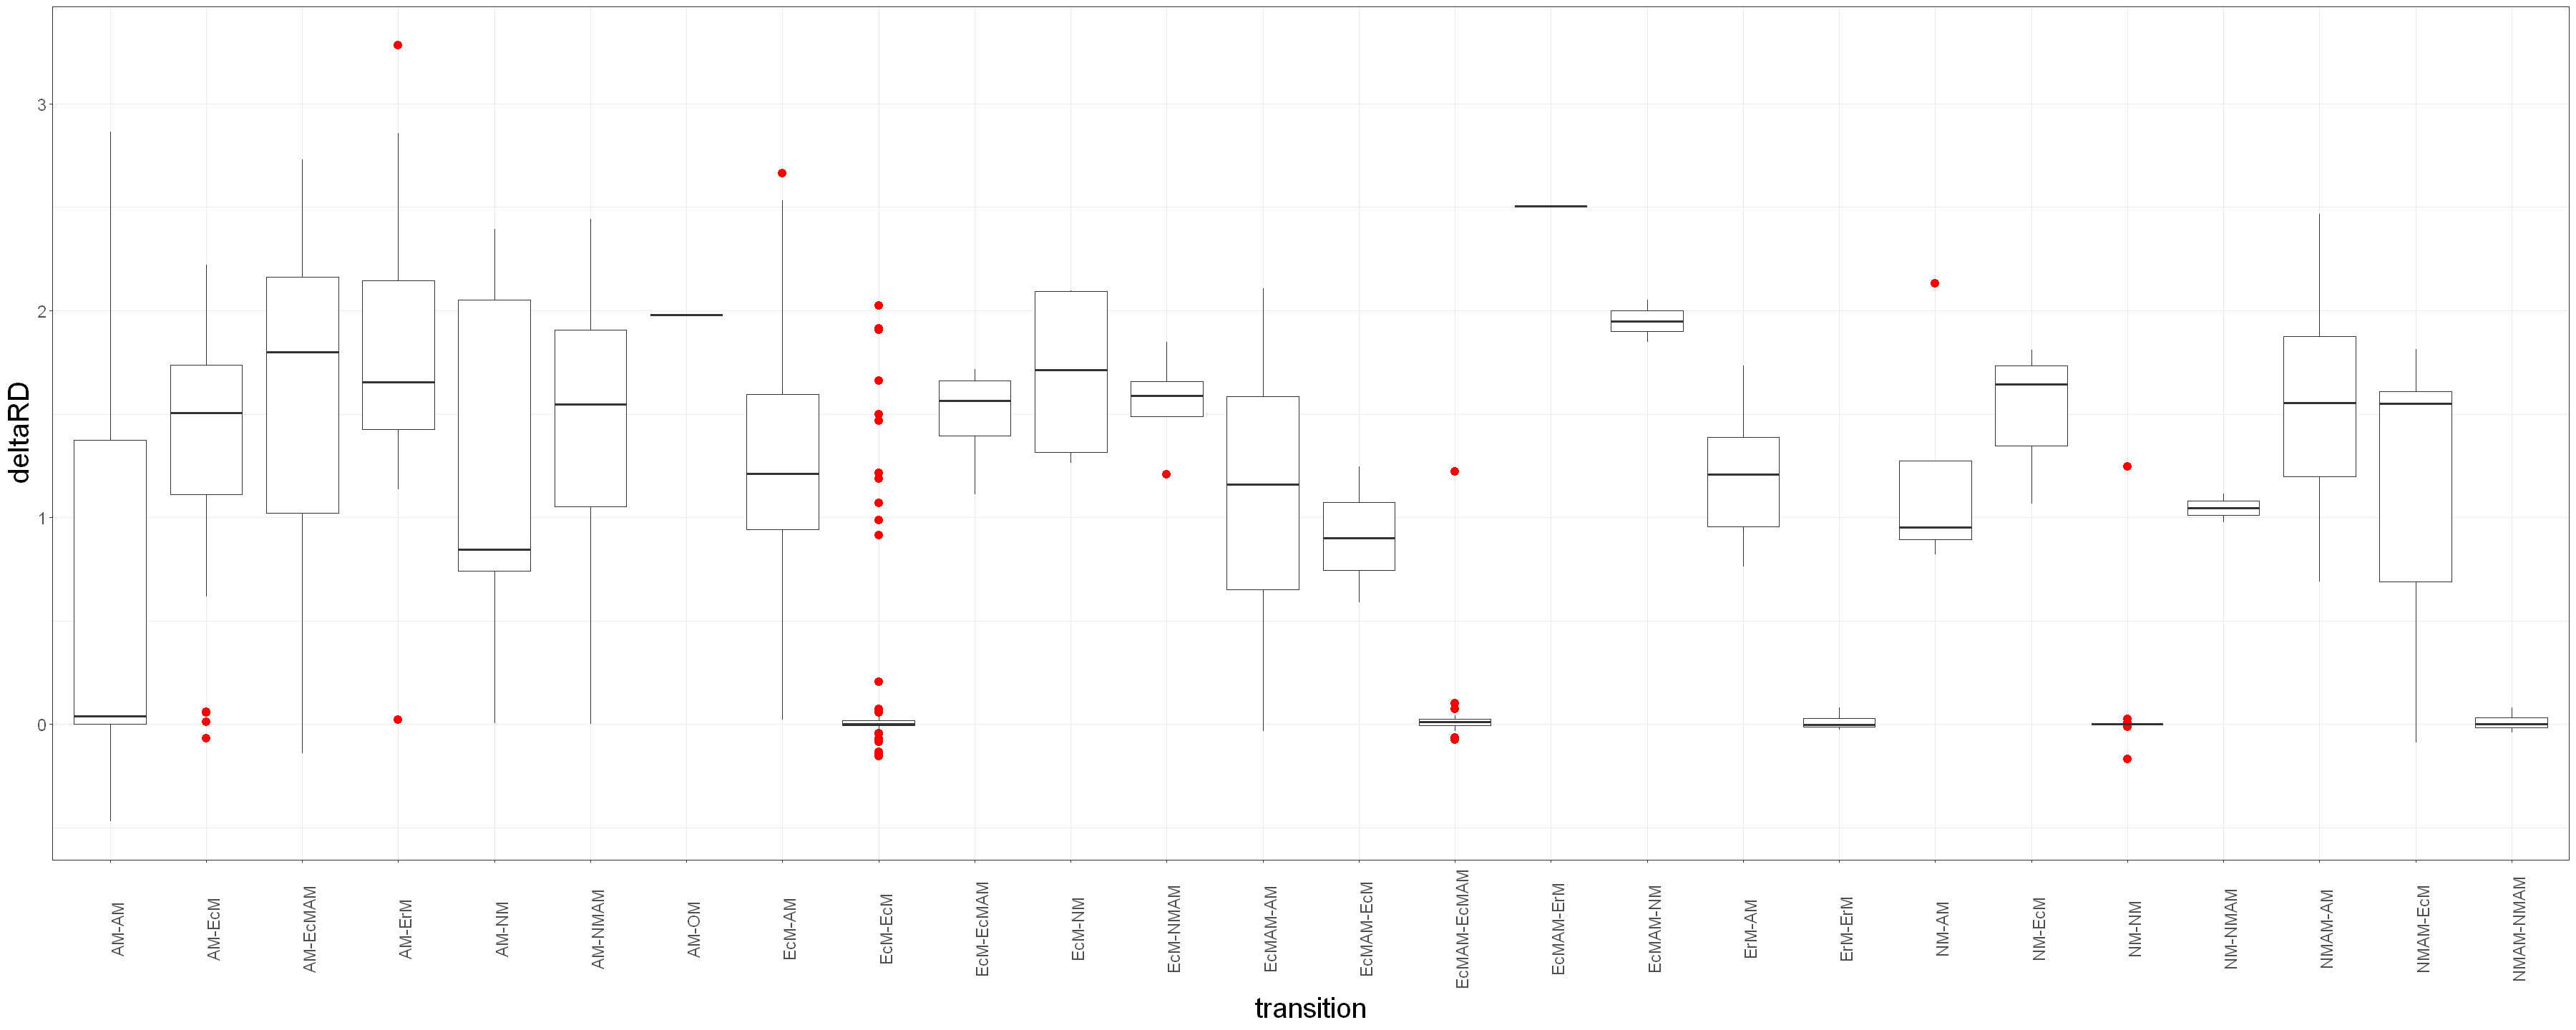

In [119]:
options(repr.plot.width = 30, repr.plot.height = 12)
ggplot2::ggplot(changes, aes(x = transition, y = deltaRD)) +
    geom_boxplot(outlier.color = "red", outlier.size = 3) +
    theme_bw() +
    theme(legend.position = "none", axis.title.x = element_text(size = 24), axis.title.y = element_text(size = 24), axis.text = element_text(size = 14), axis.text.x = element_text(angle = 90))

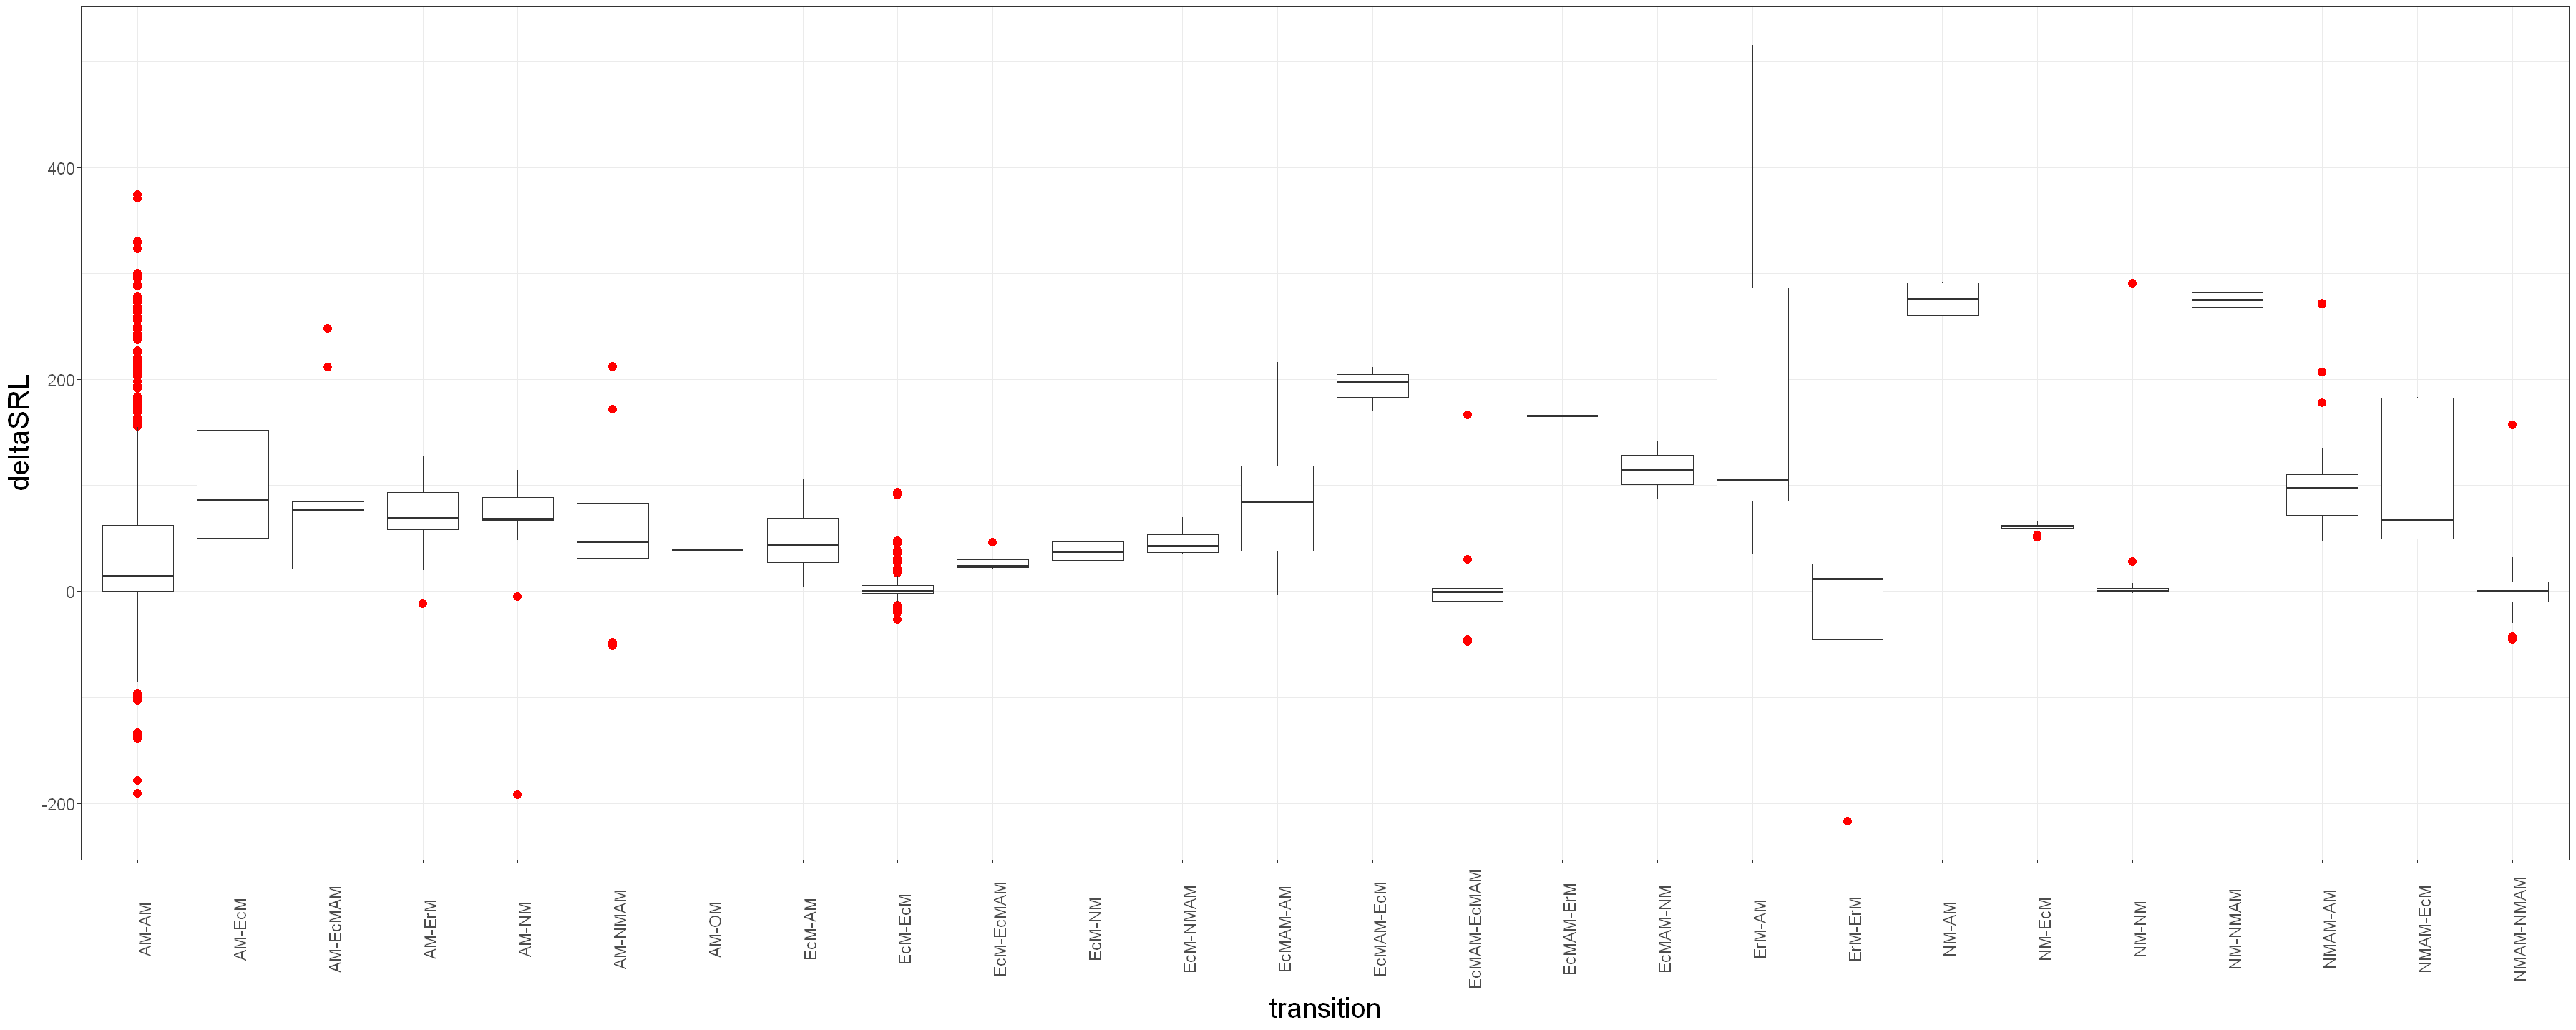

In [120]:
options(repr.plot.width = 30, repr.plot.height = 12)
ggplot2::ggplot(changes, aes(x = transition, y = deltaSRL)) +
    geom_boxplot(outlier.color = "red", outlier.size = 3) +
    theme_bw() +
    theme(legend.position = "none", axis.title.x = element_text(size = 24), axis.title.y = element_text(size = 24), axis.text = element_text(size = 14), axis.text.x = element_text(angle = 90))